In [1]:
# !pip install seaborn


[notice] A new release of pip available: 22.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
sys.path.append("..")

df_raw = pd.read_csv("../data/raw/human_vital_signs_dataset_2024.csv")
df_clean = pd.read_csv("../data/processed/icu_vitals_clean.csv", parse_dates=["timestamp"])
df_raw.head()

,Patient ID,Heart Rate,Respiratory Rate,Timestamp,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Gender,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP,Risk Category
0,1,60,12,2024-07-19 21:53:45.729841,36.861707,95.702046,124,86,37,Female,91.541618,1.679351,0.121033,38,32.459031,98.666667,High Risk
1,2,63,18,2024-07-19 21:52:45.729841,36.511633,96.689413,126,84,77,Male,50.704921,1.992546,0.117062,42,12.771246,98.000000,High Risk
2,3,63,15,2024-07-19 21:51:45.729841,37.052049,98.508265,131,78,68,Female,90.316760,1.770228,0.053200,53,28.821069,95.666667,Low Risk
3,4,99,16,2024-07-19 21:50:45.729841,36.654748,95.011801,118,72,41,Female,96.006188,1.833629,0.064475,46,28.554611,87.333333,High Risk
4,5,69,16,2024-07-19 21:49:45.729841,36.975098,98.623792,138,76,25,Female,56.020006,1.866419,0.118484,62,16.081438,96.666667,High Risk


In [3]:
# Raw data profile
print(df_raw.shape)
print(df_raw.dtypes)
df_raw.describe()

(200020, 17)
Patient ID                    int64
Heart Rate                    int64
Respiratory Rate              int64
Timestamp                    object
Body Temperature            float64
Oxygen Saturation           float64
Systolic Blood Pressure       int64
Diastolic Blood Pressure      int64
Age                           int64
Gender                       object
Weight (kg)                 float64
Height (m)                  float64
Derived_HRV                 float64
Derived_Pulse_Pressure        int64
Derived_BMI                 float64
Derived_MAP                 float64
Risk Category                object
dtype: object


,Patient ID,Heart Rate,Respiratory Rate,Body Temperature,Oxygen Saturation,Systolic Blood Pressure,Diastolic Blood Pressure,Age,Weight (kg),Height (m),Derived_HRV,Derived_Pulse_Pressure,Derived_BMI,Derived_MAP
count,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000,200020.000000
mean,100010.500000,79.533747,15.489451,36.748353,97.504372,124.437971,79.499625,53.446275,74.996419,1.750031,0.099970,44.938346,25.003625,94.479074
std,57740.944759,11.552894,2.294472,0.433290,1.442598,8.656946,5.757248,20.786802,14.471502,0.144554,0.028861,10.404945,6.447143,4.797891
min,1.000000,60.000000,12.000000,36.000004,95.000007,110.000000,70.000000,18.000000,50.000156,1.500001,0.050000,21.000000,12.505974,83.333333
25%,50005.750000,70.000000,13.000000,36.372613,96.256859,117.000000,75.000000,35.000000,62.423615,1.624777,0.074955,37.000000,20.134367,91.000000
50%,100010.500000,80.000000,15.000000,36.747741,97.509629,124.000000,79.000000,53.000000,74.977169,1.750478,0.099988,45.000000,24.320776,94.333333
75%,150015.250000,90.000000,17.000000,37.123003,98.755722,132.000000,84.000000,71.000000,87.539510,1.875310,0.124917,53.000000,29.187169,98.000000
max,200020.000000,99.000000,19.000000,37.499992,99.999963,139.000000,89.000000,89.000000,99.999765,1.999997,0.149999,69.000000,44.376487,105.666667


In [4]:
# Missingness before/after cleaning
vitals = ["heart_rate", "spo2", "resp_rate", "temperature", "systolic_bp", "diastolic_bp"]
print("Missing after cleaning:\n", df_clean[vitals].isna().mean())

Missing after cleaning:
 heart_rate      0.0
spo2            0.0
resp_rate       0.0
temperature     0.0
systolic_bp     0.0
diastolic_bp    0.0
dtype: float64


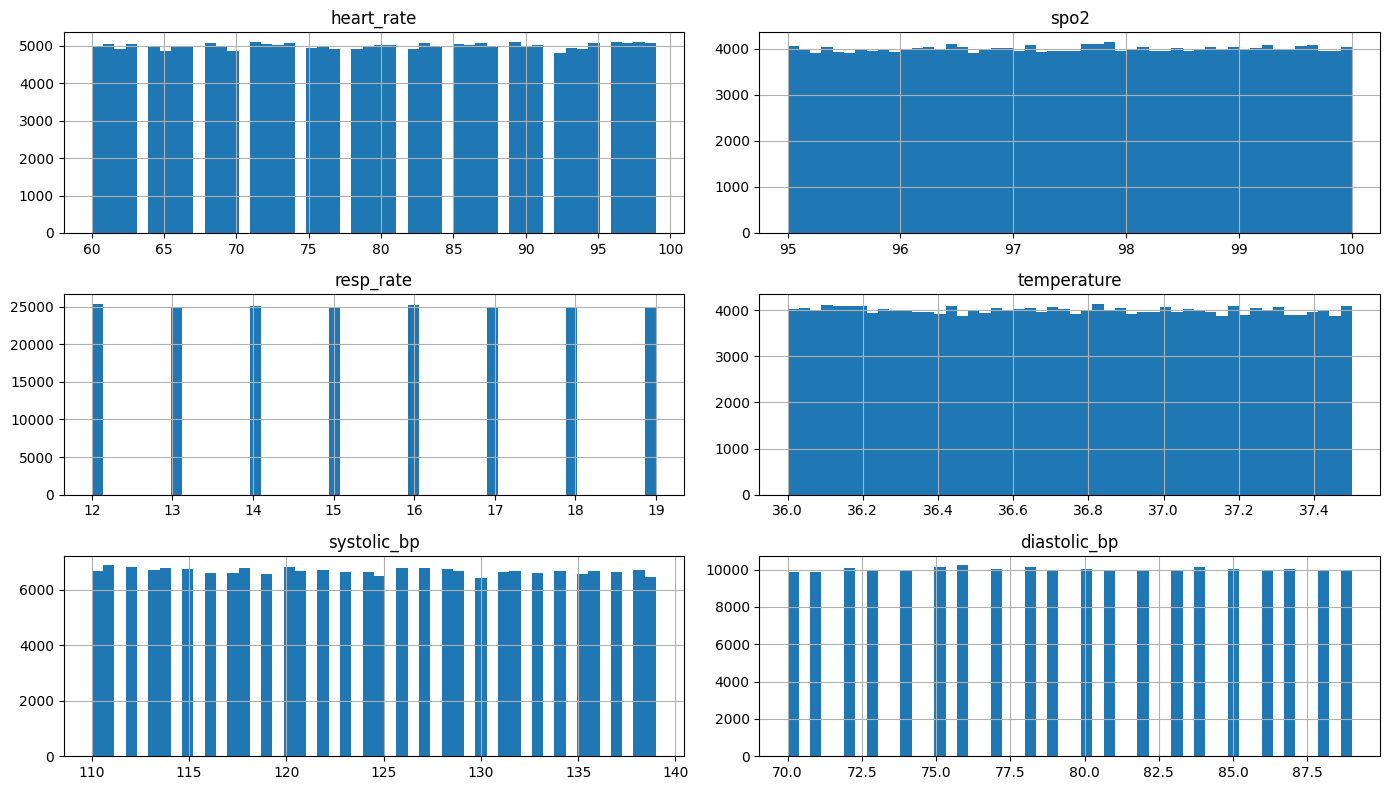

In [5]:
# Distribution of each vital — check physiological plausibility
df_clean[vitals].hist(figsize=(14, 8), bins=50)
plt.tight_layout()
plt.savefig("../results/figures/distributions.png", dpi=120)
plt.show()

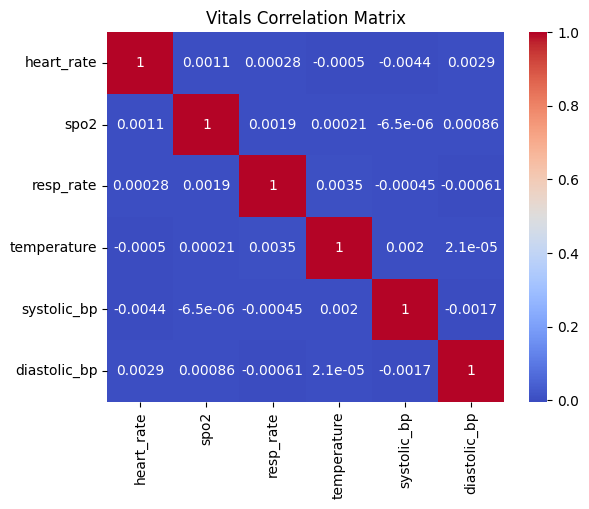

In [6]:
# Correlation matrix
corr = df_clean[vitals].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Vitals Correlation Matrix")
plt.savefig("../results/figures/correlation_matrix.png", dpi=120)
plt.show()

In [7]:
# Diagnostic Cell 1: understand patient row distribution
print("Total rows:", len(df_clean))
print("Unique patients:", df_clean["patient_id"].nunique())
print("\nRows per patient (first 10):")
print(df_clean.groupby("patient_id").size().head(10))
print("\nTimestamp range:", df_clean["timestamp"].min(), "→", df_clean["timestamp"].max())
print("\nTimestamp sample:")
print(df_clean["timestamp"].head(10))

Total rows: 200020
Unique patients: 1

Rows per patient (first 10):
patient_id
1    200020
dtype: int64

Timestamp range: 2024-03-03 00:14:00 → 2024-07-19 21:53:00

Timestamp sample:
0   2024-03-03 00:14:00
1   2024-03-03 00:15:00
2   2024-03-03 00:16:00
3   2024-03-03 00:17:00
4   2024-03-03 00:18:00
5   2024-03-03 00:19:00
6   2024-03-03 00:20:00
7   2024-03-03 00:21:00
8   2024-03-03 00:22:00
9   2024-03-03 00:23:00
Name: timestamp, dtype: datetime64[ns]


Plotting 200020 rows across timestamp range:
  2024-03-03 00:14:00  →  2024-07-19 21:53:00


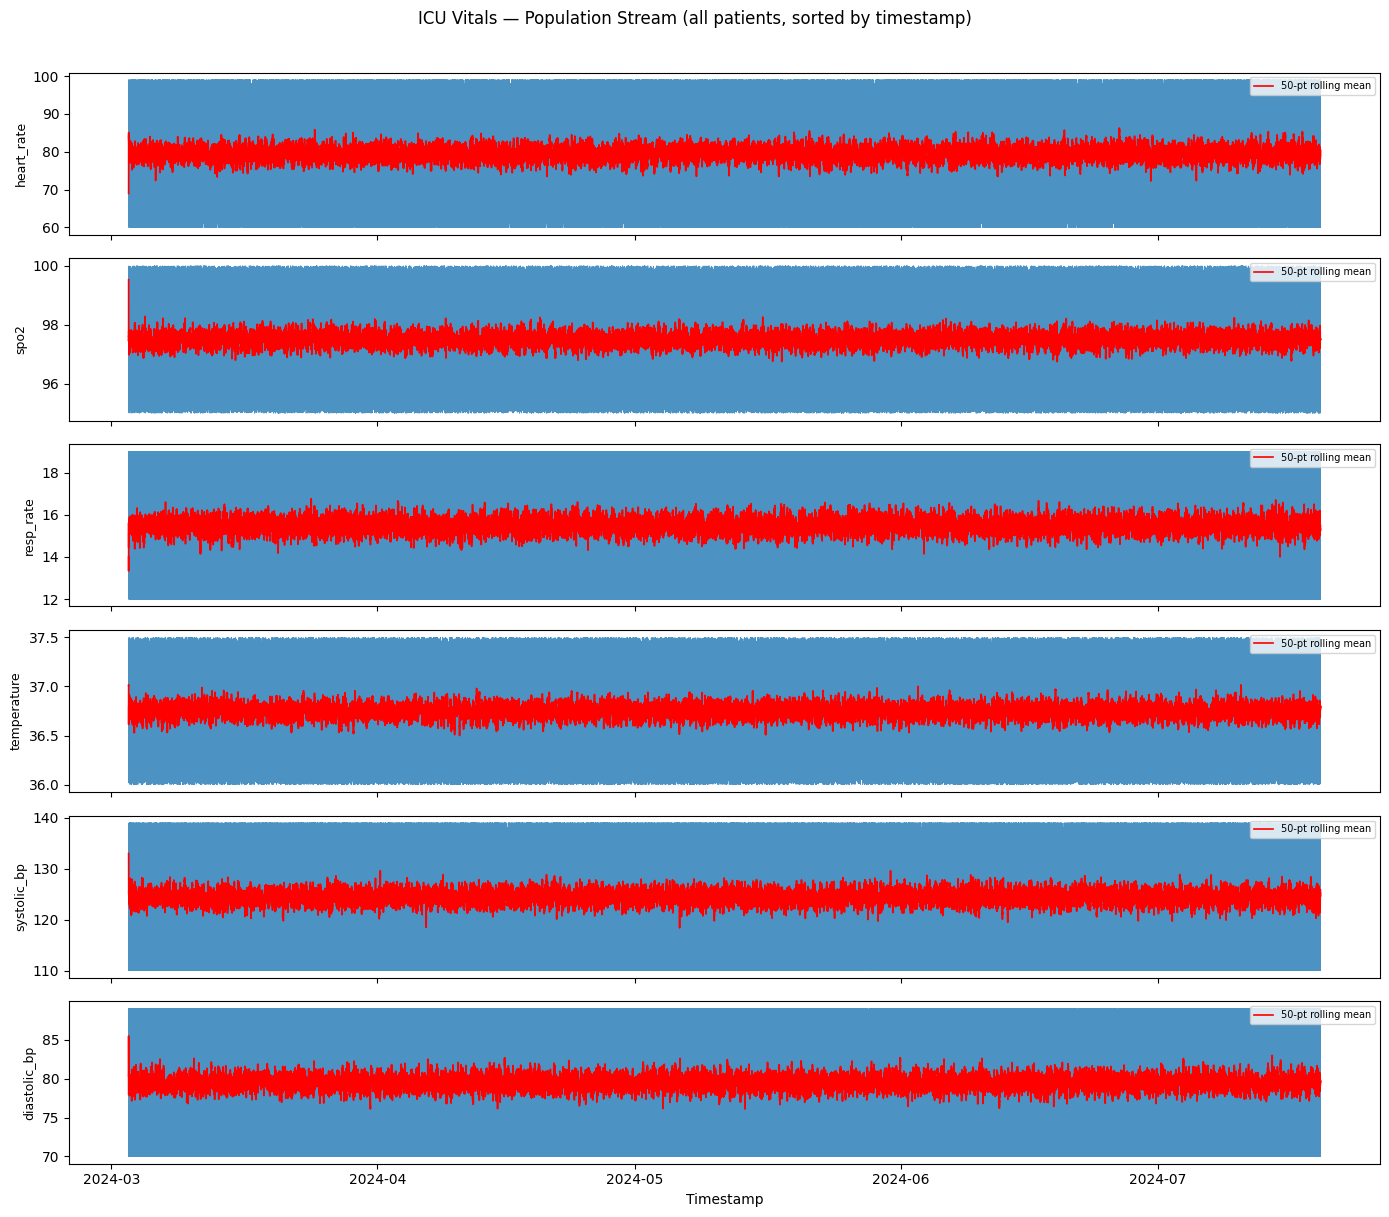

Saved → results/figures/eda_overview.png


In [8]:
# Time series for one patient (constructed time axis)
patient_df = df_clean[df_clean["patient_id"] == df_clean["patient_id"].iloc[0]]

df_stream = df_clean.sort_values("timestamp").reset_index(drop=True)

print(f"Plotting {len(df_stream)} rows across timestamp range:")
print(f"  {df_stream['timestamp'].iloc[0]}  →  {df_stream['timestamp'].iloc[-1]}")

fig, axes = plt.subplots(len(vitals), 1, figsize=(14, 12), sharex=True)
for ax, col in zip(axes, vitals):
    ax.plot(df_stream["timestamp"], df_stream[col], linewidth=0.6, alpha=0.8)
    ax.set_ylabel(col, fontsize=9)
    # Add a rolling mean line to show trend through the noise
    roll_mean = df_stream[col].rolling(window=50, min_periods=1).mean()
    ax.plot(df_stream["timestamp"], roll_mean, color="red",
            linewidth=1.2, label="50-pt rolling mean")
    ax.legend(loc="upper right", fontsize=7)

axes[-1].set_xlabel("Timestamp")
fig.suptitle("ICU Vitals — Population Stream (all patients, sorted by timestamp)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("../results/figures/eda_overview.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved → results/figures/eda_overview.png")

Shape: (200020, 65)

Rolling std variance (must be > 0):
heart_rate_roll_std_5       1.0
heart_rate_roll_std_15      1.0
heart_rate_roll_std_60      1.0
spo2_roll_std_5             1.0
spo2_roll_std_15            1.0
spo2_roll_std_60            1.0
resp_rate_roll_std_5        1.0
resp_rate_roll_std_15       1.0
resp_rate_roll_std_60       1.0
temperature_roll_std_5      1.0
temperature_roll_std_15     1.0
temperature_roll_std_60     1.0
systolic_bp_roll_std_5      1.0
systolic_bp_roll_std_15     1.0
systolic_bp_roll_std_60     1.0
diastolic_bp_roll_std_5     1.0
diastolic_bp_roll_std_15    1.0
diastolic_bp_roll_std_60    1.0
dtype: float64

Lag non-zero rate (must be ~0.99+):
heart_rate_lag_1       1.0
heart_rate_lag_5       1.0
heart_rate_lag_15      1.0
spo2_lag_1             1.0
spo2_lag_5             1.0
spo2_lag_15            1.0
resp_rate_lag_1        1.0
resp_rate_lag_5        1.0
resp_rate_lag_15       1.0
temperature_lag_1      1.0
temperature_lag_5      1.0
temperature_lag_15

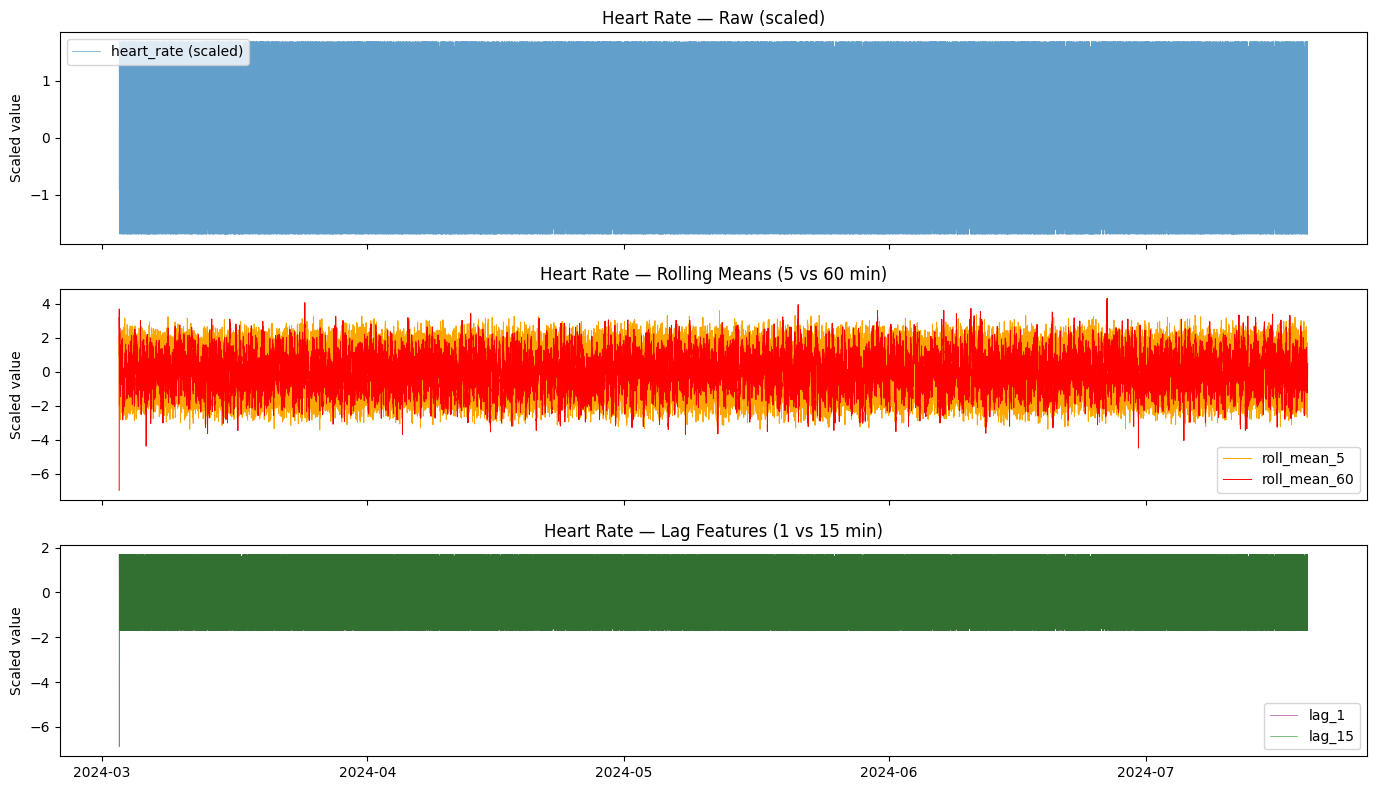

Saved → results/figures/heart_rate_features.png


In [9]:
df_feat = pd.read_csv("../data/processed/icu_vitals_features.csv",
                      parse_dates=["timestamp"])
print(f"Shape: {df_feat.shape}")

# 1. Rolling std variance — must be > 0, otherwise grouping is still broken
roll_std_cols = [c for c in df_feat.columns if "roll_std" in c]
roll_var = df_feat[roll_std_cols].var().round(4)
print("\nRolling std variance (must be > 0):")
print(roll_var)
if (roll_var == 0).any():
    print("WARNING: some rolling std columns are zero — re-run feature_engineering.py "
          "with group_col=None")

# 2. Lag non-zero rate — must be ~99%+, otherwise lag warm-up fillna(0) swamped the data
lag_cols = [c for c in df_feat.columns if "_lag_" in c]
lag_nonzero = (df_feat[lag_cols] != 0).mean().round(4)
print("\nLag non-zero rate (must be ~0.99+):")
print(lag_nonzero)

# 3. Heart rate feature plot — raw vs rolling means across the full stream
df_feat_sorted = df_feat.sort_values("timestamp").reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_feat_sorted["timestamp"], df_feat_sorted["heart_rate"],
             linewidth=0.5, alpha=0.7, label="heart_rate (scaled)")
axes[0].set_ylabel("Scaled value")
axes[0].set_title("Heart Rate — Raw (scaled)")
axes[0].legend()

axes[1].plot(df_feat_sorted["timestamp"],
             df_feat_sorted["heart_rate_roll_mean_5"],
             linewidth=0.7, color="orange", label="roll_mean_5")
axes[1].plot(df_feat_sorted["timestamp"],
             df_feat_sorted["heart_rate_roll_mean_60"],
             linewidth=0.7, color="red", label="roll_mean_60")
axes[1].set_ylabel("Scaled value")
axes[1].set_title("Heart Rate — Rolling Means (5 vs 60 min)")
axes[1].legend()

axes[2].plot(df_feat_sorted["timestamp"],
             df_feat_sorted["heart_rate_lag_1"],
             linewidth=0.5, color="purple", alpha=0.7, label="lag_1")
axes[2].plot(df_feat_sorted["timestamp"],
             df_feat_sorted["heart_rate_lag_15"],
             linewidth=0.5, color="green", alpha=0.7, label="lag_15")
axes[2].set_ylabel("Scaled value")
axes[2].set_title("Heart Rate — Lag Features (1 vs 15 min)")
axes[2].legend()

plt.tight_layout()
plt.savefig("../results/figures/heart_rate_features.png", dpi=120)
plt.show()
print("Saved → results/figures/heart_rate_features.png")